In [3]:
# ============================================================================
# CELL 0: CÀI ĐẶT THƯ VIỆN 
# ============================================================================

!pip install -q numpy opencv-python matplotlib scikit-learn gradio opencv-python-headless




[notice] A new release of pip is available: 25.0.1 -> 25.3
[notice] To update, run: C:\Users\HAD\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [4]:
import sys
!{sys.executable} -m pip install opencv-python


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: C:\Users\HAD\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [1]:
# ============================================================================
# CELL 1: SETUP & PATHS
# ============================================================================

import os
import sys
from pathlib import Path

import numpy as np
import cv2

def find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src").exists() and (p / "data").exists():
            return p
    return start

NOTEBOOK_DIR = Path.cwd().resolve()
REPO_ROOT = find_repo_root(NOTEBOOK_DIR)

print("NOTEBOOK_DIR:", NOTEBOOK_DIR)
print("REPO_ROOT:", REPO_ROOT)


SCALE = 2

TRAIN_LR_DIR = REPO_ROOT / "data" / "degraded_lr" / f"LR_x{SCALE}"
TRAIN_HR_DIR = REPO_ROOT / "data" / "input_hr"    / f"HR_x{SCALE}"

TEST_LR_DIR  = REPO_ROOT / "data" / "target_lr"   / f"LR_x{SCALE}"
TEST_HR_DIR  = REPO_ROOT / "data" / "target_hr"   / f"HR_x{SCALE}"

OUT_DIR  = REPO_ROOT / "outputs" / f"aplus_x{SCALE}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR  = REPO_ROOT / "checkpoints"
CKPT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_PATH = CKPT_DIR / f"aplus_x{SCALE}.pkl"

print("\nDATA PATHS")
print("  Train LR:", TRAIN_LR_DIR)
print("  Train HR:", TRAIN_HR_DIR)
print("  Test  LR:", TEST_LR_DIR)
print("  Test  HR:", TEST_HR_DIR)
print("  Checkpoint:", CKPT_PATH)
print("  Outputs:", OUT_DIR)


NOTEBOOK_DIR: C:\Users\HAD\Desktop\temp\image_super_resolution_traditional_cv\notebooks
REPO_ROOT: C:\Users\HAD\Desktop\temp\image_super_resolution_traditional_cv

DATA PATHS
  Train LR: C:\Users\HAD\Desktop\temp\image_super_resolution_traditional_cv\data\degraded_lr\LR_x2
  Train HR: C:\Users\HAD\Desktop\temp\image_super_resolution_traditional_cv\data\input_hr\HR_x2
  Test  LR: C:\Users\HAD\Desktop\temp\image_super_resolution_traditional_cv\data\target_lr\LR_x2
  Test  HR: C:\Users\HAD\Desktop\temp\image_super_resolution_traditional_cv\data\target_hr\HR_x2
  Checkpoint: C:\Users\HAD\Desktop\temp\image_super_resolution_traditional_cv\checkpoints\aplus_x2.pkl
  Outputs: C:\Users\HAD\Desktop\temp\image_super_resolution_traditional_cv\outputs\aplus_x2


In [2]:
# ============================================================================
# CELL 2: HYPERPARAMETERS (APlusConfig)
# ============================================================================

from dataclasses import dataclass

@dataclass
class APlusConfig:
    scale: int = 2
    patch_size: int = 7
    step: int = 3
    n_anchors: int = 512
    pca_dim: int = 50
    ridge_lambda: float = 5e-3
    rng_seed: int = 42

    k_neighbors: int = 512

    max_patches: int | None = None 

cfg = APlusConfig(
    scale=SCALE,
    patch_size=7,
    step=3,
    n_anchors=512,
    pca_dim=50,
    ridge_lambda=5e-3,
    rng_seed=42,
    k_neighbors=512,
    max_patches=None, 
)

cfg


APlusConfig(scale=2, patch_size=7, step=3, n_anchors=512, pca_dim=50, ridge_lambda=0.005, rng_seed=42, k_neighbors=512, max_patches=None)

In [3]:
# ============================================================================
# CELL 3: CORE IMPLEMENTATION (A+)
# ============================================================================

import pickle
from dataclasses import dataclass
from typing import List, Tuple

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

def rgb2yiq(rgb: np.ndarray) -> np.ndarray:
    """RGB [0,1] -> YIQ."""
    M = np.array([
        [0.299,     0.587,     0.114    ],
        [0.595716, -0.274453, -0.321263 ],
        [0.211456, -0.522591,  0.311135 ],
    ], dtype=np.float32)
    resh = rgb.reshape(-1, 3).astype(np.float32)
    yiq = resh @ M.T
    return yiq.reshape(rgb.shape)

def yiq2rgb(yiq: np.ndarray) -> np.ndarray:
    """YIQ -> RGB [0,1]."""
    M_inv = np.array([
        [1.0,  0.9563,  0.6210],
        [1.0, -0.2721, -0.6474],
        [1.0, -1.1070,  1.7046],
    ], dtype=np.float32)
    resh = yiq.reshape(-1, 3).astype(np.float32)
    rgb = resh @ M_inv.T
    return rgb.reshape(yiq.shape)

def y_bt601_from_rgb_u8(rgb_u8: np.ndarray) -> np.ndarray:
    r = rgb_u8[...,0].astype(np.float32)
    g = rgb_u8[...,1].astype(np.float32)
    b = rgb_u8[...,2].astype(np.float32)
    return (16.0 + 65.481*(r/255.0) + 128.553*(g/255.0) + 24.966*(b/255.0))

def shave(img: np.ndarray, s: int) -> np.ndarray:
    if s <= 0:
        return img
    h, w = img.shape[:2]
    if h <= 2*s or w <= 2*s:
        return img
    return img[s:-s, s:-s]

def psnr_y_shave(hr_rgb_u8: np.ndarray, pr_rgb_u8: np.ndarray, scale: int) -> float:
    yh = shave(y_bt601_from_rgb_u8(hr_rgb_u8), scale)
    yp = shave(y_bt601_from_rgb_u8(pr_rgb_u8), scale)
    H = min(yh.shape[0], yp.shape[0])
    W = min(yh.shape[1], yp.shape[1])
    if H == 0 or W == 0:
        return float("nan")
    diff = (yh[:H,:W] - yp[:H,:W]).astype(np.float32)
    mse = float(np.mean(diff*diff))
    if mse <= 1e-12:
        return 99.0
    return 10.0 * np.log10((255.0*255.0)/mse)


def feature_map_from_y(Y: np.ndarray) -> np.ndarray:
    Yf = Y.astype(np.float32)
    gx = cv2.Sobel(Yf, cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(Yf, cv2.CV_32F, 0, 1, ksize=3)
    lap = cv2.Laplacian(Yf, cv2.CV_32F, ksize=3)
    F = np.stack([Yf, gx, gy, lap], axis=-1)
    return F

def extract_patches_from_feature_map(F: np.ndarray, patch_size: int, step: int) -> Tuple[np.ndarray, List[Tuple[int,int]]]:
    H, W, C = F.shape
    ps = int(patch_size)
    st = int(step)

    ys = list(range(0, max(1, H-ps+1), st))
    xs = list(range(0, max(1, W-ps+1), st))
    if ys[-1] != H - ps:
        ys.append(H - ps)
    if xs[-1] != W - ps:
        xs.append(W - ps)

    coords = []
    vecs = []
    for y in ys:
        for x in xs:
            patch = F[y:y+ps, x:x+ps, :] 
            vecs.append(patch.reshape(-1))
            coords.append((y, x))

    if not vecs:
        return np.empty((0, ps*ps*C), np.float32), []

    X_raw = np.asarray(vecs, dtype=np.float32)
    return X_raw, coords

def extract_y_patches(Y: np.ndarray, coords: List[Tuple[int,int]], patch_size: int) -> np.ndarray:
    ps = int(patch_size)
    patches = [Y[y:y+ps, x:x+ps].reshape(-1) for (y,x) in coords]
    if not patches:
        return np.empty((0, ps*ps), np.float32)
    return np.asarray(patches, dtype=np.float32)

def reconstruct_from_patches(coords: List[Tuple[int,int]],
                             patches: np.ndarray,
                             H: int, W: int,
                             patch_size: int,
                             window: str = "hann") -> np.ndarray:
    ps = int(patch_size)
    if window == "hann":
        wy = np.hanning(ps).astype(np.float32)
        wx = np.hanning(ps).astype(np.float32)
        w2 = np.outer(wy, wx)
        w2[w2 == 0] = 1e-6
    else:
        w2 = np.ones((ps, ps), np.float32)

    out = np.zeros((H, W), np.float32)
    wgt = np.zeros((H, W), np.float32)

    k = 0
    for (y, x) in coords:
        patch = patches[k].reshape(ps, ps).astype(np.float32)
        out[y:y+ps, x:x+ps] += patch * w2
        wgt[y:y+ps, x:x+ps] += w2
        k += 1

    wgt[wgt == 0] = 1.0
    return out / wgt


def _pair_train_images(lr_dir: Path, hr_dir: Path) -> List[Tuple[Path, Path]]:
    lr_files = sorted([p for p in lr_dir.iterdir()
                       if p.suffix.lower() in (".png",".jpg",".jpeg",".bmp",".tif",".tiff")])
    pairs = []
    for lr_p in lr_files:
        hr_name = lr_p.name.replace("_LR", "_HR")
        hr_p = hr_dir / hr_name
        if hr_p.exists():
            pairs.append((lr_p, hr_p))
    return pairs

def build_training_matrices(lr_dir: str, hr_dir: str, cfg: APlusConfig) -> Tuple[np.ndarray, np.ndarray]:
    lr_dir = Path(lr_dir)
    hr_dir = Path(hr_dir)

    pairs = _pair_train_images(lr_dir, hr_dir)
    if not pairs:
        raise RuntimeError(f"No LR/HR training pairs found in {lr_dir} vs {hr_dir}")

    X_list = []
    Y_list = []
    S = cfg.scale
    ps = cfg.patch_size
    st = cfg.step

    print(f"[build_training_matrices] Found {len(pairs)} LR/HR pairs")

    for i, (lr_p, hr_p) in enumerate(pairs, 1):
   
        lr_bgr = cv2.imread(str(lr_p), cv2.IMREAD_COLOR)
        hr_bgr = cv2.imread(str(hr_p), cv2.IMREAD_COLOR)
        if lr_bgr is None or hr_bgr is None:
            continue

        lr_rgb = cv2.cvtColor(lr_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
        hr_rgb = cv2.cvtColor(hr_bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0

        H_lr, W_lr = lr_rgb.shape[:2]
        H_hr, W_hr = hr_rgb.shape[:2]
        if H_hr != H_lr*S or W_hr != W_lr*S:
            hr_rgb = cv2.resize(hr_rgb, (W_lr*S, H_lr*S), interpolation=cv2.INTER_CUBIC)
            H_hr, W_hr = hr_rgb.shape[:2]

        yiq_lr = rgb2yiq(lr_rgb)
        Y_lr = yiq_lr[...,0]

        Y_up = cv2.resize(Y_lr, (W_hr, H_hr), interpolation=cv2.INTER_CUBIC)

        Y_hr = rgb2yiq(hr_rgb)[...,0]

        F = feature_map_from_y(Y_up)
        X_raw_i, coords = extract_patches_from_feature_map(F, ps, st)
        if not coords:
            continue

        Y_up_p = extract_y_patches(Y_up, coords, ps)
        Y_hr_p = extract_y_patches(Y_hr, coords, ps)
        Y_res  = Y_hr_p - Y_up_p

        X_list.append(X_raw_i)
        Y_list.append(Y_res)

        print(f"  [{i}/{len(pairs)}] {lr_p.name}: {X_raw_i.shape[0]} patches")

    if not X_list:
        raise RuntimeError("No training patches extracted.")

    X_raw = np.concatenate(X_list, axis=0).astype(np.float32)
    Y     = np.concatenate(Y_list, axis=0).astype(np.float32)
    print(f"[build_training_matrices] Total patches: {X_raw.shape[0]}")

    if cfg.max_patches is not None and X_raw.shape[0] > cfg.max_patches:
        N = X_raw.shape[0]
        idx = np.random.choice(N, cfg.max_patches, replace=False)
        X_raw = X_raw[idx]
        Y     = Y[idx]
        print(f"[build_training_matrices] Subsampled to {cfg.max_patches} patches")

    return X_raw, Y


@dataclass
class APlusModel:
    cfg: APlusConfig
    pca: PCA
    kmeans: KMeans
    projections: List[np.ndarray]
    feat_dim: int
    patch_dim: int


def train_aplus(lr_dir: str, hr_dir: str, cfg: APlusConfig) -> APlusModel:
    np.random.seed(cfg.rng_seed)

    X_raw, Y = build_training_matrices(lr_dir, hr_dir, cfg)
    assert X_raw.shape[0] > 0

    print("[train_aplus] PCA fit...")
    pca = PCA(n_components=min(cfg.pca_dim, X_raw.shape[1]),
              random_state=cfg.rng_seed, whiten=True)
    X = pca.fit_transform(X_raw).astype(np.float32)
    d = X.shape[1]
    m = Y.shape[1]

    print("[train_aplus] KMeans fit...")
    kmeans = KMeans(n_clusters=cfg.n_anchors,
                    random_state=cfg.rng_seed,
                    n_init="auto")
    kmeans.fit(X)
    centers = kmeans.cluster_centers_.astype(np.float32)

    print("[train_aplus] Anchor-wise ridge regression...")
    x2 = np.sum(X*X, axis=1, keepdims=True)                       
    c2 = np.sum(centers*centers, axis=1, keepdims=True).T        
    dist2 = x2 + c2 - 2.0*(X @ centers.T)                        
    labels = np.argmin(dist2, axis=1)                            
    projections: List[np.ndarray] = []
    I = np.eye(d, dtype=np.float32)
    K_fix = int(cfg.k_neighbors)

    for a in range(cfg.n_anchors):
        cand = np.where(labels == a)[0]
        if cand.size == 0:
            projections.append(np.zeros((d, m), np.float32))
            continue

        order = np.argsort(dist2[cand, a])
        K_a   = min(K_fix, cand.size)
        idx   = cand[order[:K_a]]

        Xa = X[idx]
        Ya = Y[idx]

        XtX = Xa.T @ Xa
        XtY = Xa.T @ Ya
        P   = np.linalg.solve(XtX + cfg.ridge_lambda * I, XtY)    # (d,m)
        projections.append(P.astype(np.float32))

        if (a+1) % max(1, cfg.n_anchors//10) == 0:
            print(f"  anchor {a+1}/{cfg.n_anchors}: K={K_a}, patches total={cand.size}")

    model = APlusModel(cfg=cfg, pca=pca, kmeans=kmeans,
                       projections=projections,
                       feat_dim=d, patch_dim=m)

    model.P_list = projections
    model.centers_pca = centers
    return model


def save_model(path: str, model: APlusModel) -> None:
    with open(path, "wb") as f:
        pickle.dump(model, f)
    print(f"[save_model] Saved model to {path}")

def load_model(path: str) -> APlusModel:
    with open(path, "rb") as f:
        model: APlusModel = pickle.load(f)
    print(f"[load_model] Loaded model from {path}")
    return model

def sr_anrplus(lr_input, model: APlusModel) -> np.ndarray:
    cfg = model.cfg
    s   = int(cfg.scale)
    ps  = int(cfg.patch_size)
    st  = int(cfg.step)

    # lr_input cA3 thA� lA� path (str/Path) ho���c a���nh numpy tA1 Gradio
    if isinstance(lr_input, (str, Path)):
        bgr = cv2.imread(str(lr_input), cv2.IMREAD_COLOR)
        if bgr is None:
            raise FileNotFoundError(str(lr_input))
        rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    else:
        rgb = np.asarray(lr_input)
        if rgb.ndim == 2:
            rgb = np.stack([rgb, rgb, rgb], axis=-1)
        if rgb.dtype != np.float32:
            rgb = rgb.astype(np.float32) / 255.0

    H_lr, W_lr = rgb.shape[:2]
    H_hr, W_hr = H_lr*s, W_lr*s

    yiq = rgb2yiq(rgb)
    Y_lr, I_lr, Q_lr = yiq[...,0], yiq[...,1], yiq[...,2]

    Y_up = cv2.resize(Y_lr, (W_hr, H_hr), interpolation=cv2.INTER_CUBIC)
    I_up = cv2.resize(I_lr, (W_hr, H_hr), interpolation=cv2.INTER_CUBIC)
    Q_up = cv2.resize(Q_lr, (W_hr, H_hr), interpolation=cv2.INTER_CUBIC)

    F = feature_map_from_y(Y_up)
    X_raw, coords = extract_patches_from_feature_map(F, ps, st)
    if not coords:
        Y_pred = Y_up
    else:
        X = model.pca.transform(X_raw).astype(np.float32)         
        centers = model.centers_pca                          
        x2 = np.sum(X*X, axis=1, keepdims=True)
        c2 = np.sum(centers*centers, axis=1, keepdims=True).T
        dist2 = x2 + c2 - 2.0*(X @ centers.T)                   
        a_idx = np.argmin(dist2, axis=1)                       

        P_any = model.P_list
        N = X.shape[0]
        res_vec = np.empty((N, ps*ps), np.float32)

        for a in np.unique(a_idx):
            idx = np.where(a_idx == a)[0]
            Pa  = P_any[a]                                     
            res_vec[idx] = X[idx] @ Pa                          

        res_map = reconstruct_from_patches(coords, res_vec, H_hr, W_hr, ps, window="hann")
        Y_pred  = np.clip(Y_up + res_map, 0.0, 1.0)

    out_yiq = np.stack([Y_pred, I_up, Q_up], axis=-1)
    out_rgb = yiq2rgb(out_yiq)
    out_rgb = np.clip(out_rgb, 0.0, 1.0)
    return (out_rgb*255.0 + 0.5).astype(np.uint8)


def eval_set_psnr_yshave(model: APlusModel, lr_dir: Path, hr_dir: Path) -> Tuple[float, float]:
    pairs = _pair_train_images(lr_dir, hr_dir)  
    if not pairs:
        raise RuntimeError(f"No pairs in {lr_dir} vs {hr_dir}")

    psnrs = []
    for i, (lr_p, hr_p) in enumerate(pairs, 1):
        lr_path = str(lr_p)
        hr_bgr  = cv2.imread(str(hr_p), cv2.IMREAD_COLOR)
        hr_rgb  = cv2.cvtColor(hr_bgr, cv2.COLOR_BGR2RGB)
        sr_rgb  = sr_anrplus(lr_path, model)
        if sr_rgb.shape[:2] != hr_rgb.shape[:2]:
            sr_rgb = cv2.resize(sr_rgb, (hr_rgb.shape[1], hr_rgb.shape[0]), interpolation=cv2.INTER_CUBIC)
        p = psnr_y_shave(hr_rgb, sr_rgb, model.cfg.scale)
        psnrs.append(p)
        print(f"  [{i}/{len(pairs)}] {lr_p.name}: PSNR_Y+shave(A+) = {p:.3f} dB")

    mean_psnr = float(np.mean(psnrs))
    print(f"\n[eval_set_psnr_yshave] Mean PSNR (Y+shave) on {len(pairs)} images: {mean_psnr:.3f} dB")
    return mean_psnr, float(len(pairs))


In [5]:
# ============================================================================
# CELL 4: TRAIN HOẶC LOAD MODEL
# ============================================================================

from pathlib import Path

if CKPT_PATH.exists():
    print("Checkpoint found, loading model...")
    model = load_model(str(CKPT_PATH))
else:
    print("No checkpoint found, training A+ model from scratch...")
    print("Training data:")
    print("  LR:", TRAIN_LR_DIR)
    print("  HR:", TRAIN_HR_DIR)
    model = train_aplus(str(TRAIN_LR_DIR), str(TRAIN_HR_DIR), cfg)
    save_model(str(CKPT_PATH), model)

print("\nModel config:")
print(model.cfg)
print("feat_dim (PCA dim):", model.feat_dim, " patch_dim:", model.patch_dim)
print("n_anchors:", model.cfg.n_anchors)


Checkpoint found, loading model...
[load_model] Loaded model from C:\Users\HAD\Desktop\temp\image_super_resolution_traditional_cv\checkpoints\aplus_x2.pkl

Model config:
APlusConfig(scale=2, patch_size=7, step=3, n_anchors=512, pca_dim=50, ridge_lambda=0.005, rng_seed=42, k_neighbors=512, max_patches=None)
feat_dim (PCA dim): 50  patch_dim: 49
n_anchors: 512


Demo image: img_002_SRF_2_LR.png
Demo PSNR (Y+shave) A+ vs HR: 38.708 dB
Saved demo images to: C:\Users\HAD\Desktop\temp\image_super_resolution_traditional_cv\outputs\aplus_x2


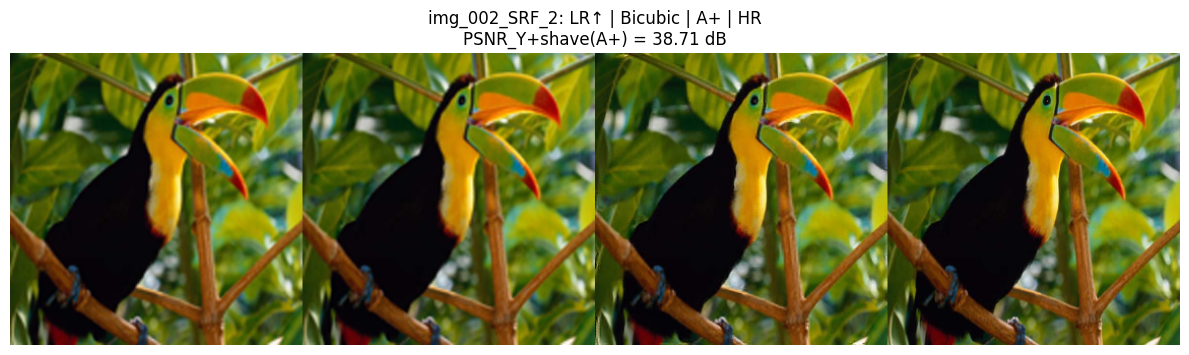


Evaluating on full test set...
  [1/5] img_001_SRF_2_LR.png: PSNR_Y+shave(A+) = 37.457 dB
  [2/5] img_002_SRF_2_LR.png: PSNR_Y+shave(A+) = 38.708 dB
  [3/5] img_003_SRF_2_LR.png: PSNR_Y+shave(A+) = 29.889 dB
  [4/5] img_004_SRF_2_LR.png: PSNR_Y+shave(A+) = 35.073 dB
  [5/5] img_005_SRF_2_LR.png: PSNR_Y+shave(A+) = 32.663 dB

[eval_set_psnr_yshave] Mean PSNR (Y+shave) on 5 images: 34.758 dB

Test set (5.0 images) mean PSNR (Y+shave): 34.758 dB


In [6]:
# ============================================================================
# CELL 5: INFERENCE DEMO + EVALUATE TEST SET + SAVE IMAGES
# ============================================================================

import matplotlib.pyplot as plt

pairs_test = _pair_train_images(TEST_LR_DIR, TEST_HR_DIR)
if not pairs_test:
    raise RuntimeError(f"No test pairs found in {TEST_LR_DIR} vs {TEST_HR_DIR}")

lr_demo, hr_demo = pairs_test[1]
name = lr_demo.stem.replace("_LR", "")
print("Demo image:", lr_demo.name)

lr_bgr_demo = cv2.imread(str(lr_demo), cv2.IMREAD_COLOR)
hr_bgr_demo = cv2.imread(str(hr_demo), cv2.IMREAD_COLOR)
lr_rgb_demo = cv2.cvtColor(lr_bgr_demo, cv2.COLOR_BGR2RGB)
hr_rgb_demo = cv2.cvtColor(hr_bgr_demo, cv2.COLOR_BGR2RGB)

H_lr, W_lr = lr_rgb_demo.shape[:2]
lr_up_demo = cv2.resize(lr_rgb_demo,
                        (W_lr * SCALE, H_lr * SCALE),
                        interpolation=cv2.INTER_CUBIC)
bic_rgb_demo = lr_up_demo.copy()

sr_demo = sr_anrplus(str(lr_demo), model)

H_hr, W_hr = hr_rgb_demo.shape[:2]
if bic_rgb_demo.shape[:2] != (H_hr, W_hr):
    bic_rgb_demo = cv2.resize(bic_rgb_demo, (W_hr, H_hr), interpolation=cv2.INTER_CUBIC)
if sr_demo.shape[:2] != (H_hr, W_hr):
    sr_demo = cv2.resize(sr_demo, (W_hr, H_hr), interpolation=cv2.INTER_CUBIC)

ps_demo = psnr_y_shave(hr_rgb_demo, sr_demo, SCALE)
print(f"Demo PSNR (Y+shave) A+ vs HR: {ps_demo:.3f} dB")

cv2.imwrite(str(OUT_DIR / f"{name}_lr_up.png"),
            cv2.cvtColor(lr_up_demo, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUT_DIR / f"{name}_bicubic.png"),
            cv2.cvtColor(bic_rgb_demo, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUT_DIR / f"{name}_aplus.png"),
            cv2.cvtColor(sr_demo, cv2.COLOR_RGB2BGR))
cv2.imwrite(str(OUT_DIR / f"{name}_hr.png"),
            cv2.cvtColor(hr_rgb_demo, cv2.COLOR_RGB2BGR))

comp = np.concatenate([lr_up_demo, bic_rgb_demo, sr_demo, hr_rgb_demo], axis=1)
cv2.imwrite(str(OUT_DIR / f"{name}_lrup_bic_aplus_hr.png"),
            cv2.cvtColor(comp, cv2.COLOR_RGB2BGR))

print("Saved demo images to:", OUT_DIR)

plt.figure(figsize=(12, 4))
plt.imshow(comp)
plt.title(f"{name}: LR↑ | Bicubic | A+ | HR\nPSNR_Y+shave(A+) = {ps_demo:.2f} dB")
plt.axis("off")
plt.tight_layout()
plt.show()

print("\nEvaluating on full test set...")
mean_psnr, n_imgs = eval_set_psnr_yshave(model, TEST_LR_DIR, TEST_HR_DIR)
print(f"\nTest set ({n_imgs} images) mean PSNR (Y+shave): {mean_psnr:.3f} dB")


In [ ]:
import shutil, random, json

def data_dirs_for_scale(scale: int):
    train_lr = REPO_ROOT / "data" / "degraded_lr" / f"LR_x{scale}"
    train_hr = REPO_ROOT / "data" / "input_hr"    / f"HR_x{scale}"
    test_lr  = REPO_ROOT / "data" / "target_lr"   / f"LR_x{scale}"
    test_hr  = REPO_ROOT / "data" / "target_hr"   / f"HR_x{scale}"
    return train_lr, train_hr, test_lr, test_hr

def build_subset_for_scale(scale: int, train_lr_full: Path, train_hr_full: Path, val_ratio: float = 0.15):
    subset_root = REPO_ROOT / "data_subsets_tmp" / f"x{scale}"
    if subset_root.exists():
        shutil.rmtree(subset_root)
    subset_root.mkdir(parents=True, exist_ok=True)
    train_lr_sub = subset_root / "train_lr"
    train_hr_sub = subset_root / "train_hr"
    val_lr_sub   = subset_root / "val_lr"
    val_hr_sub   = subset_root / "val_hr"
    train_lr_sub.mkdir(parents=True, exist_ok=True)
    train_hr_sub.mkdir(parents=True, exist_ok=True)
    val_lr_sub.mkdir(parents=True, exist_ok=True)
    val_hr_sub.mkdir(parents=True, exist_ok=True)

    lr_files = sorted([p for p in train_lr_full.iterdir()
                       if p.suffix.lower() in (".png",".jpg",".jpeg",".bmp",".tif",".tiff")])
    n = len(lr_files)
    idx_all = list(range(n))
    random.Random(100 + scale).shuffle(idx_all)
    split = max(1, int(n * (1 - val_ratio)))
    train_idx = idx_all[:split]
    val_idx   = idx_all[split:]

    def copy_indices(idxs, dst_lr, dst_hr):
        for i in idxs:
            lr_p = lr_files[i]
            hr_name = lr_p.name.replace("_LR", "_HR")
            hr_p = train_hr_full / hr_name
            if not hr_p.exists():
                continue
            shutil.copy2(lr_p, dst_lr / lr_p.name)
            shutil.copy2(hr_p, dst_hr / hr_p.name)

    copy_indices(train_idx, train_lr_sub, train_hr_sub)
    copy_indices(val_idx,   val_lr_sub,   val_hr_sub)

    return train_lr_sub, train_hr_sub, val_lr_sub, val_hr_sub

config_grid = {
    3: [
        {"patch_size":9, "step":3, "n_anchors":512,  "pca_dim":60, "ridge_lambda":7e-3, "k_neighbors":512},
        {"patch_size":9, "step":3, "n_anchors":1024, "pca_dim":60, "ridge_lambda":7e-3, "k_neighbors":1024},
        {"patch_size":9, "step":3, "n_anchors":1024, "pca_dim":60, "ridge_lambda":5e-3, "k_neighbors":1024},
    ],
    4: [
        {"patch_size":11,"step":3, "n_anchors":1024, "pca_dim":60, "ridge_lambda":1e-2, "k_neighbors":1024},
        {"patch_size":11,"step":3, "n_anchors":1024, "pca_dim":60, "ridge_lambda":7e-3, "k_neighbors":1024},
        {"patch_size":9, "step":3, "n_anchors":1024, "pca_dim":60, "ridge_lambda":1e-2, "k_neighbors":1024},
    ],
}

results_summary = {}

for scale in [3, 4]:
    train_lr_full, train_hr_full, test_lr_full, test_hr_full = data_dirs_for_scale(scale)
    if not train_lr_full.exists() or not train_hr_full.exists():
        print(f"Skip scale x{scale}: train dirs not found")
        continue

    print("="*70)
    print(f"SCALE x{scale}: build subset and grid search")
    train_lr_sub, train_hr_sub, val_lr_sub, val_hr_sub = build_subset_for_scale(scale, train_lr_full, train_hr_full, val_ratio=0.15)
    cfg_list = config_grid[scale]

    best_psnr = -1e9
    best_cfg_dict = None

    for i, cd in enumerate(cfg_list, 1):
        cfg_local = APlusConfig(
            scale=scale,
            patch_size=cd["patch_size"],
            step=cd["step"],
            n_anchors=cd["n_anchors"],
            pca_dim=cd["pca_dim"],
            ridge_lambda=cd["ridge_lambda"],
            rng_seed=42 + scale,
            k_neighbors=cd["k_neighbors"],
            max_patches=2_000_000,
        )
        print(f"[x{scale}] config {i}/{len(cfg_list)}:", cfg_local)
        model_tmp = train_aplus(str(train_lr_sub), str(train_hr_sub), cfg_local)
        psnr_val = eval_set_psnr_yshave(model_tmp, val_lr_sub, val_hr_sub)
        if isinstance(psnr_val, tuple):
            psnr_val, n_val_imgs = psnr_val
        print(f"[x{scale}]  val PSNR_Y+shave = {psnr_val:.3f} dB")

        if psnr_val > best_psnr:
            best_psnr = psnr_val
            best_cfg_dict = cd.copy()

    if best_cfg_dict is None:
        print(f"No valid config for scale x{scale}")
        continue

    best_cfg_full = APlusConfig(
        scale=scale,
        patch_size=best_cfg_dict["patch_size"],
        step=best_cfg_dict["step"],
        n_anchors=best_cfg_dict["n_anchors"],
        pca_dim=best_cfg_dict["pca_dim"],
        ridge_lambda=best_cfg_dict["ridge_lambda"],
        rng_seed=42 + scale,
        k_neighbors=best_cfg_dict["k_neighbors"],
        max_patches=None,
    )

    print(f"[x{scale}] BEST VAL CONFIG:", best_cfg_full, "with PSNR =", best_psnr)
    model_best = train_aplus(str(train_lr_full), str(train_hr_full), best_cfg_full)
    ckpt_path = CKPT_DIR / f"anrplus_x{scale}.pkl"
    save_model(str(ckpt_path), model_best)
    print(f"[x{scale}] Saved best model to {ckpt_path}")

    results_summary[scale] = {
        "best_val_psnr": float(best_psnr),
        "cfg": {
            "patch_size": best_cfg_full.patch_size,
            "step": best_cfg_full.step,
            "n_anchors": best_cfg_full.n_anchors,
            "pca_dim": best_cfg_full.pca_dim,
            "ridge_lambda": best_cfg_full.ridge_lambda,
            "k_neighbors": best_cfg_full.k_neighbors,
        },
    }

res_json_path = REPO_ROOT / "gridsearch_anrplus_summary.json"
with open(res_json_path, "w") as f:
    json.dump(results_summary, f, indent=2)
print("Saved summary to", res_json_path)


SCALE x3: build subset and grid search
[x3] config 1/3: APlusConfig(scale=3, patch_size=9, step=3, n_anchors=512, pca_dim=60, ridge_lambda=0.007, rng_seed=45, k_neighbors=512, max_patches=2000000)
[build_training_matrices] Found 85 LR/HR pairs
  [1/85] img_001_SRF_3_LR.png: 16590 patches
  [2/85] img_002_SRF_3_LR.png: 16590 patches
  [3/85] img_003_SRF_3_LR.png: 16590 patches
  [4/85] img_004_SRF_3_LR.png: 16590 patches
  [5/85] img_005_SRF_3_LR.png: 16590 patches
  [6/85] img_006_SRF_3_LR.png: 16590 patches
  [7/85] img_007_SRF_3_LR.png: 16590 patches
  [8/85] img_008_SRF_3_LR.png: 16590 patches
  [9/85] img_009_SRF_3_LR.png: 16590 patches
  [10/85] img_011_SRF_3_LR.png: 16590 patches
  [11/85] img_012_SRF_3_LR.png: 16590 patches
  [12/85] img_013_SRF_3_LR.png: 16590 patches
  [13/85] img_014_SRF_3_LR.png: 16590 patches
  [14/85] img_015_SRF_3_LR.png: 16590 patches
  [15/85] img_017_SRF_3_LR.png: 16590 patches
  [16/85] img_018_SRF_3_LR.png: 16590 patches
  [17/85] img_019_SRF_3_LR.pn

In [ ]:
import gradio as gr

_model_cache = {}

def get_model_for_scale(scale: int):
    if scale in _model_cache:
        return _model_cache[scale]
    ckpt_path = CKPT_DIR / f"anrplus_x{scale}.pkl"
    if not ckpt_path.exists():
        raise FileNotFoundError(f"Checkpoint not found for scale x{scale}: {ckpt_path}")
    m = load_model(str(ckpt_path))
    _model_cache[scale] = m
    return m

def gradio_anrplus_multiscale(lr_img, scale):
    if lr_img is None:
        return None, None, None, "No image."
    scale = int(scale)
    try:
        model_s = get_model_for_scale(scale)
    except FileNotFoundError as e:
        return None, None, None, str(e)
    S = model_s.cfg.scale
    lr_rgb = lr_img.astype("uint8")
    H_lr, W_lr = lr_rgb.shape[:2]
    lr_up = cv2.resize(lr_rgb, (W_lr*S, H_lr*S), interpolation=cv2.INTER_CUBIC)
    sr_rgb = sr_anrplus(lr_rgb, model_s)
    info = (
        f"Scale x{S}\n"
        f"LR: {W_lr}x{H_lr}\n"
        f"HR: {W_lr*S}x{H_lr*S}\n\n"
        f"patch_size={model_s.cfg.patch_size}, step={model_s.cfg.step}\n"
        f"n_anchors={model_s.cfg.n_anchors}, pca_dim={model_s.cfg.pca_dim}\n"
        f"k_neighbors={model_s.cfg.k_neighbors}, ridge_lambda={model_s.cfg.ridge_lambda}"
    )
    return lr_rgb, lr_up, sr_rgb, info

def run_gradio_multiscale():
    with gr.Blocks() as demo:
        gr.Markdown("ANR+ Super-Resolution Demo (x2/x3/x4)")
        with gr.Row():
            inp = gr.Image(label="Upload LR image", type="numpy")
            scale_dd = gr.Dropdown(choices=["2","3","4"], value="2", label="Scale")
        out_lr  = gr.Image(label="LR", type="numpy")
        out_bic = gr.Image(label="LR↑ Bicubic", type="numpy")
        out_sr  = gr.Image(label="ANR+ SR", type="numpy")
        out_info = gr.Markdown()

        def _update(lr_img, scale):
            return gradio_anrplus_multiscale(lr_img, scale)

        inp.change(_update, inputs=[inp, scale_dd], outputs=[out_lr, out_bic, out_sr, out_info])
        scale_dd.change(_update, inputs=[inp, scale_dd], outputs=[out_lr, out_bic, out_sr, out_info])

    demo.launch()

run_gradio_multiscale()


c:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


[load_model] Loaded model from C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\checkpoints\anrplus_x2.pkl
[load_model] Loaded model from C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\checkpoints\anrplus_x3.pkl
[load_model] Loaded model from C:\Users\HAD\Desktop\ML\image_super_resolution_traditional_cv\checkpoints\anrplus_x4.pkl
